# EXPLORATION AND VISUALIZATION

## Area of Study: Visualization

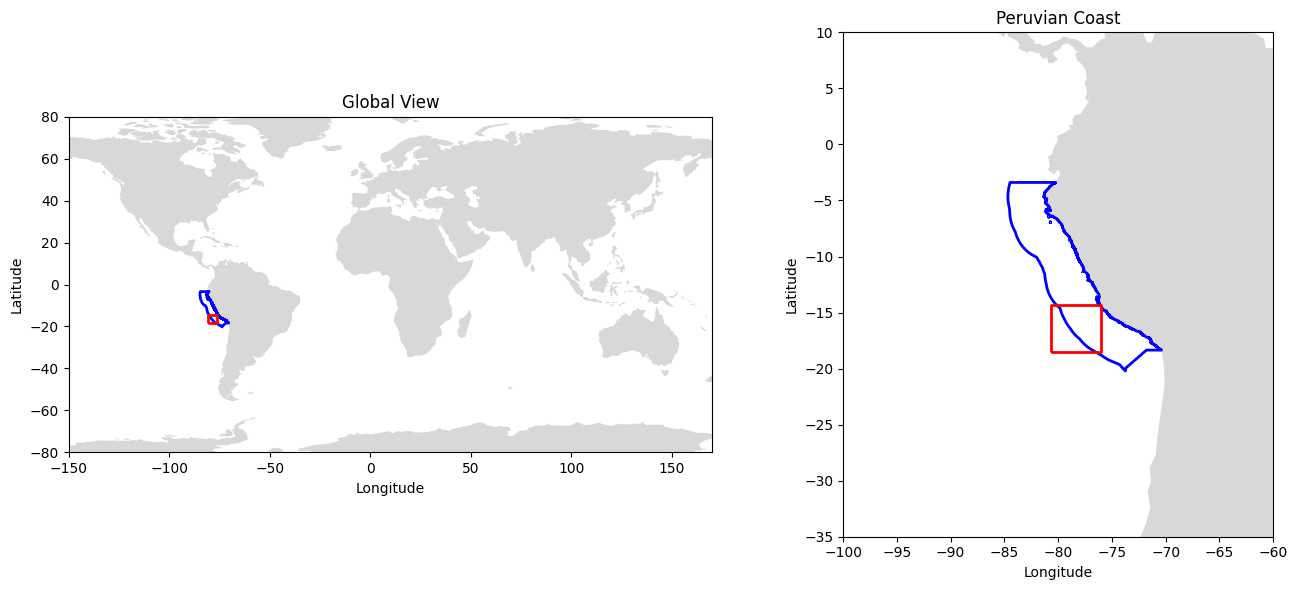

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
from pathlib import Path

BASE_DIR = Path.cwd().parent
EEZ_FILE = BASE_DIR / "data/eez/eez.shp"

eez = gpd.read_file(EEZ_FILE).to_crs("EPSG:4326")

study_gdf = gpd.GeoDataFrame(
    geometry=[box(-80.7, -18.5, -76, -14.3)],
    crs="EPSG:4326"
)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")

def plot_map(ax, xlim, ylim, title):
    world.plot(ax=ax, color="grey", alpha=0.3)
    eez.boundary.plot(ax=ax, color="blue", linewidth=2)
    study_gdf.boundary.plot(ax=ax, color="red", linewidth=2)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_map(
    axes[0],
    (-150, 170),
    (-80, 80),
    "Global View"
)

plot_map(
    axes[1],
    (-100, -60),
    (-35, 10),
    "Peruvian Coast"
)

plt.savefig(BASE_DIR / "outputs/maps/area_of_study.png")

plt.tight_layout()
plt.show()

The area of study was chosen such that the area is roughly split between Peru's EEZ and international waters. This exact square was chosen because it showed reasonable fishing activity on both sides of the EEZ line year round, which should contain enough data to draw meaningful conclusions.

## Yearly Analysis: Inside vs Outside EEZ

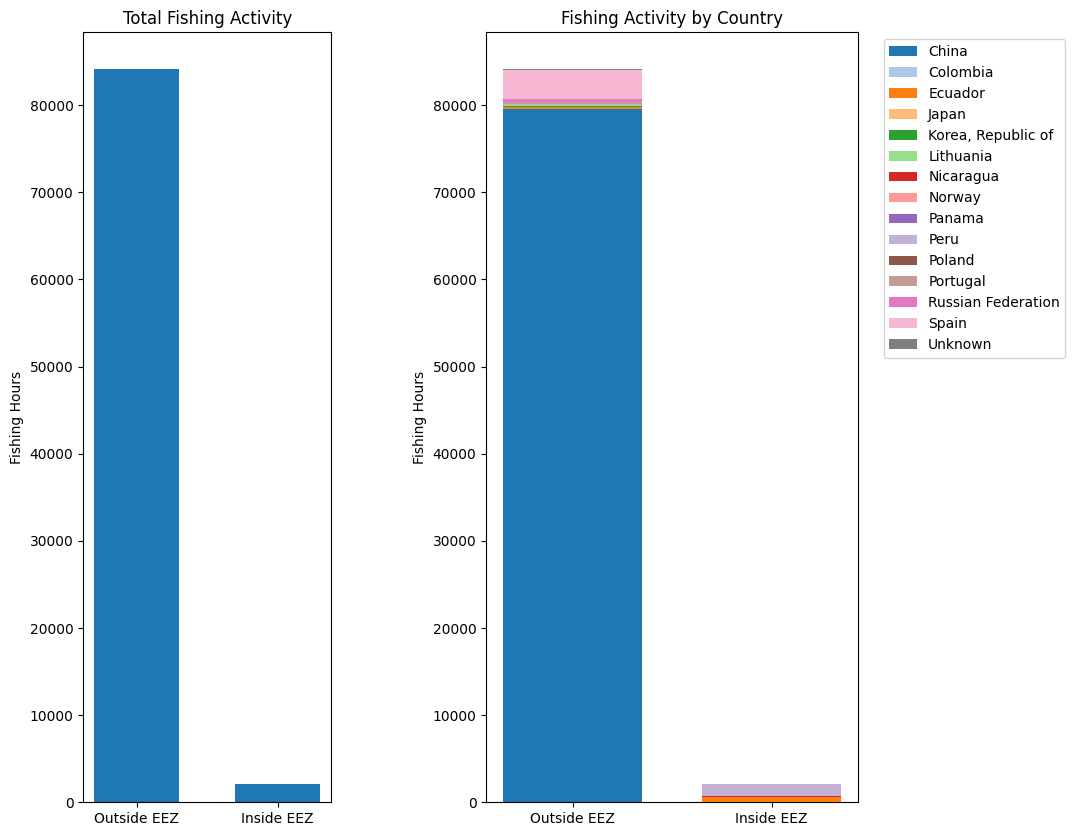

In [2]:
df_country = pd.read_csv(BASE_DIR / "data/final/year_country_percentage_eez.csv")
df_total = pd.read_csv(BASE_DIR / "data/final/year_eez.csv")

df_country = df_country.groupby(
    ["inside_eez", "country_name"],
    as_index=False
)["fishing_hours"].sum()

pivot = df_country.pivot(
    index="inside_eez",
    columns="country_name",
    values="fishing_hours"
).fillna(0)

pivot = pivot.reindex([False, True])

# prep total
df_total = df_total.set_index("inside_eez").reindex([False, True]).reset_index()
total_values = df_total["fishing_hours"].values

x_labels = ["Outside EEZ", "Inside EEZ"]

# figure
fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(10, 10),  
    gridspec_kw={"width_ratios": [1, 1.5]}  # right plot slightly bigger
)

# left - total bar
ax_left.bar(
    x_labels,
    total_values,
    width=0.6
)

ax_left.set_title("Total Fishing Activity")
ax_left.set_ylabel("Fishing Hours")

# right: per country bar
bottom = [0, 0]
colors = plt.cm.tab20.colors

country_colors = {
    c: colors[i % len(colors)] for i, c in enumerate(pivot.columns)
}

for country in pivot.columns:
    values = pivot[country].values

    ax_right.bar(
        x_labels,
        values,
        bottom=bottom,
        label=country,
        color=country_colors[country],
        width=0.7
    )

    bottom = bottom + values

ax_right.set_title("Fishing Activity by Country")
ax_right.set_ylabel("Fishing Hours")

ax_right.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.subplots_adjust(wspace=0.5)

plt.savefig(BASE_DIR / "outputs/figures/yearly_activity_bar.png")

plt.show()

For what is a relatively arbitary patch of ocean, there is a disproportionately large amount of fishing activity outside Peru's EEZ compared to inside. The second graphic reveals that, year-round, over 90% of that international-water fishing activity can be attributed to chinese vessels. In its own waters, Peru is responsible for about half of the fishing activity, and combined with Ecuador, comprise basically all of the fishing activity in the EEZ.

In [3]:
df = pd.read_csv(BASE_DIR / "data/final/year_country_eez.csv")

df_false = df[df["inside_eez"] == False]
df_true = df[df["inside_eez"] == True]

top5_false = df_false.sort_values(by="fishing_hours", ascending=False).head(5)
top5_true = df_true.sort_values(by="fishing_hours", ascending=False).head(5)

top5_false = top5_false.drop(columns=["inside_eez"])
top5_true = top5_true.drop(columns=["inside_eez"])

In [4]:
from IPython.display import display, HTML

left = top5_false.reset_index(drop=True).to_html(index=False)
right = top5_true.reset_index(drop=True).to_html(index=False)

html = f"""
<div style="display: flex; gap: 100px;">
    <div>
        <h3>Top 5 (Outside EEZ)</h3>
        {left}
    </div>
    <div>
        <h3>Top 5 (Inside EEZ)</h3>
        {right}
    </div>
</div>
"""

display(HTML(html))

country_name,fishing_hours
China,79551.2
Spain,3355.4
Russian Federation,382.6
Ecuador,221.5
Portugal,194.8
country_name,fishing_hours
Peru,1346.2
Ecuador,602.4
Nicaragua,66.8
Panama,39.4


Through 2024 China fished almost 60x more hours than Peru in an area of ocean half-owned by Peru. In the water just outside Peru's EEZ, Spain fished almost 3x as much as Peru did in its own waters. The data supports the idea that Peru's fisheries are exploited by larger scale international fishing operations. 

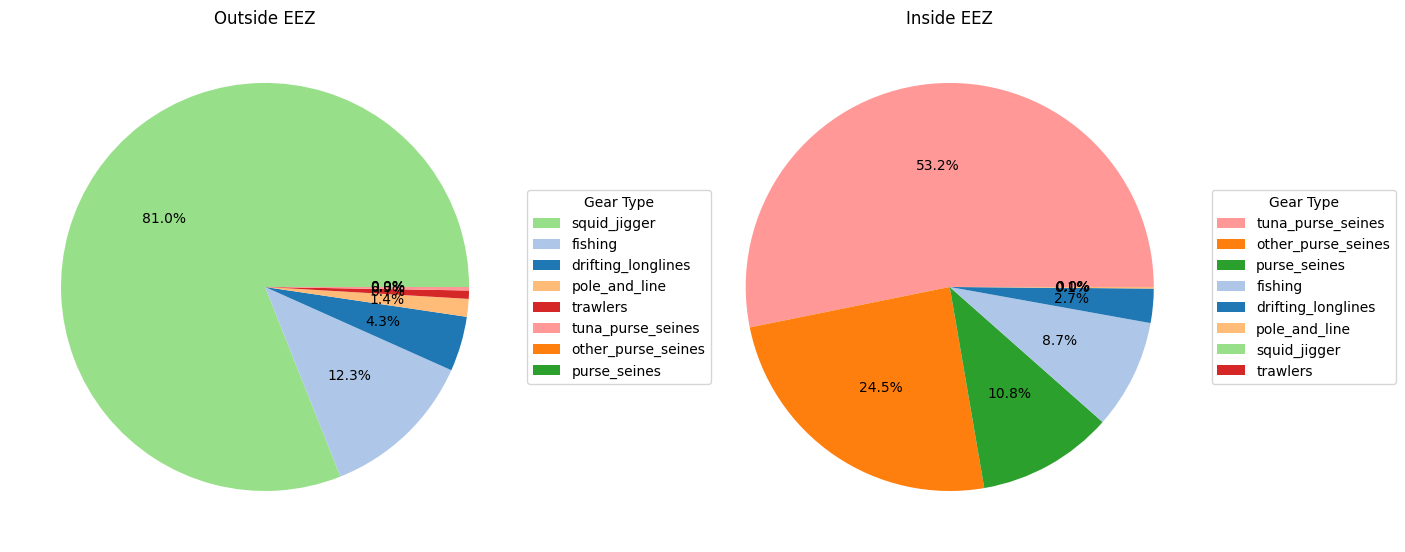

In [5]:
df = pd.read_csv(BASE_DIR / "data/final/year_gear_eez.csv")

df_false = df[df["inside_eez"] == False]
df_true = df[df["inside_eez"] == True]

# all labels
all_labels = sorted(df["geartype"].dropna().unique())

# colormap
cmap = plt.get_cmap("tab20")
color_map = {label: cmap(i % 20) for i, label in enumerate(all_labels)}

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6))

# OUTSIDE EEZ
colors_false = [color_map[label] for label in df_false["geartype"]]

wedges1, _, _ = ax_left.pie(
    df_false["fishing_hours"],
    colors=colors_false,
    autopct="%1.1f%%"
)
ax_left.set_title("Outside EEZ")

ax_left.legend(
    wedges1,
    df_false["geartype"],
    title="Gear Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# INSIDE EEZ
colors_true = [color_map[label] for label in df_true["geartype"]]

wedges2, _, _ = ax_right.pie(
    df_true["fishing_hours"],
    colors=colors_true,
    autopct="%1.1f%%"
)
ax_right.set_title("Inside EEZ")

ax_right.legend(
    wedges2,
    df_true["geartype"],
    title="Gear Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/figures/gear_pie.png")
plt.show()

It is interesting that fishing activity inside the EEZ is mostly with seines (large nets) while outside it is dominated by squid jigger and fishing vessels. 

## Monthly Analysis:

### Totals:

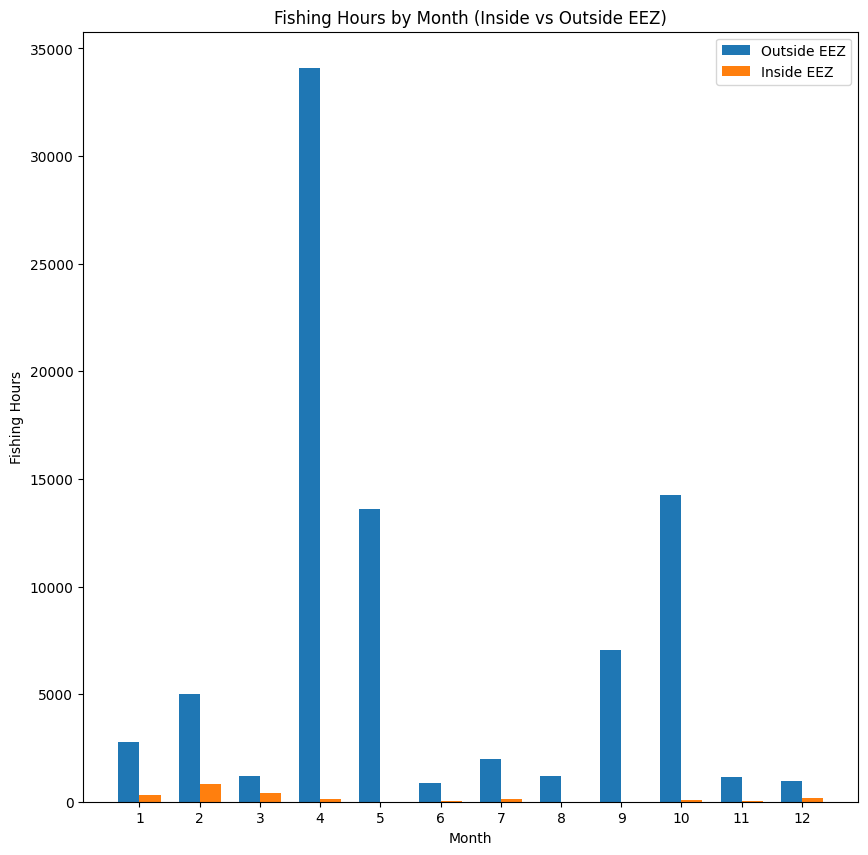

In [6]:
import numpy as np

month = list(range(1, 13))
data_t = []
data_f = []

for i in range(12):
    df = pd.read_csv(BASE_DIR / f"data/final/month_{i+1:02d}_eez.csv")

    df_false = df[df["inside_eez"] == False]
    data_f.append(float(df_false["fishing_hours"].iloc[0]))

    df_true = df[df["inside_eez"] == True]
    data_t.append(float(df_true["fishing_hours"].iloc[0]))

months = np.array(month)
x = np.arange(len(months))  # positions on x-axis

width = 0.35  # bar width

plt.figure(figsize=(10, 10))

plt.bar(x - width/2, data_f, width, label="Outside EEZ")
plt.bar(x + width/2, data_t, width, label="Inside EEZ")

plt.xticks(x, months)
plt.xlabel("Month")
plt.ylabel("Fishing Hours")
plt.title("Fishing Hours by Month (Inside vs Outside EEZ)")
plt.legend()

plt.savefig(BASE_DIR / "outputs/figures/monthy_bar.png")

plt.show()

For the fishing activity inside the EEZ, the most productive months of the year are from December to March. For the fishing activity outside the EEZ the most productive months are April, May, September, and October. Since the differences are so large on this chart, below is a normalized chart showing the relative share of fishing activity each month.

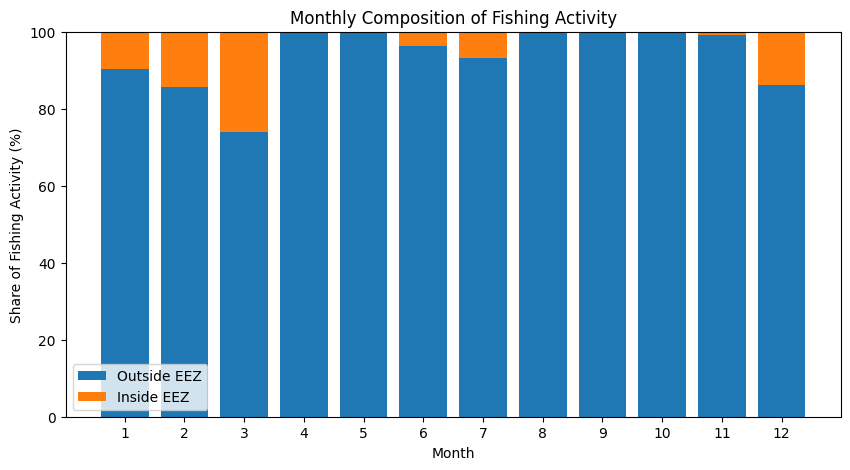

In [7]:
import numpy as np
import matplotlib.pyplot as plt

months = np.array(month)
x = np.arange(len(months))

data_f = np.array(data_f)
data_t = np.array(data_t)

total = data_f + data_t

data_f_pct = (data_f / total) * 100
data_t_pct = (data_t / total) * 100

plt.figure(figsize=(10, 5))

plt.bar(x, data_f_pct, label="Outside EEZ")
plt.bar(x, data_t_pct, bottom=data_f_pct, label="Inside EEZ")

plt.xticks(x, months)
plt.xlabel("Month")
plt.ylabel("Share of Fishing Activity (%)")
plt.title("Monthly Composition of Fishing Activity")
plt.legend()

plt.savefig(BASE_DIR / "outputs/figures/monthly_bar_norm.png")

plt.show()

### Foreign Presence:

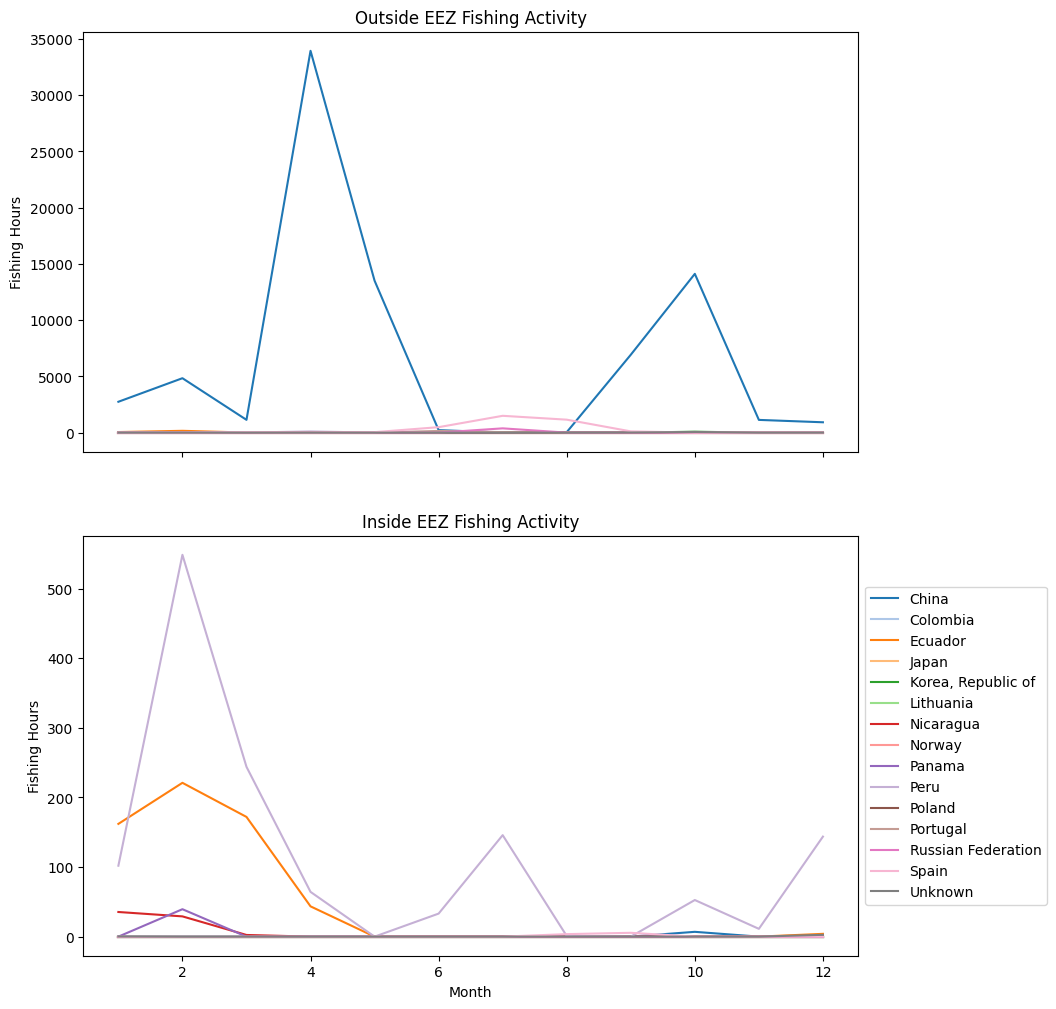

In [8]:
from collections import defaultdict

data_f = defaultdict(lambda: [0]*12)
data_t = defaultdict(lambda: [0]*12)

all_countries = set()

for i in range(12):
    df = pd.read_csv(BASE_DIR / f"data/final/month_{i+1:02d}_country_eez.csv")

    df_false = df[df["inside_eez"] == False]
    df_true = df[df["inside_eez"] == True]

    for _, row in df_false.iterrows():
        country = row["country_name"]
        data_f[country][i] = row["fishing_hours"]
        all_countries.add(country)

    for _, row in df_true.iterrows():
        country = row["country_name"]
        data_t[country][i] = row["fishing_hours"]
        all_countries.add(country)

all_countries = sorted(all_countries)

cmap = plt.get_cmap("tab20")
color_map = {c: cmap(i % 20) for i, c in enumerate(all_countries)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

x = months

# OUTSIDE EEZ
for country in all_countries:
    ax1.plot(x, data_f[country], label=country, color=color_map[country])

ax1.set_title("Outside EEZ Fishing Activity")
ax1.set_ylabel("Fishing Hours")

# INSIDE EEZ
for country in all_countries:
    ax2.plot(x, data_t[country], label=country, color=color_map[country])

ax2.set_title("Inside EEZ Fishing Activity")
ax2.set_xlabel("Month")
ax2.set_ylabel("Fishing Hours")

ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.savefig(BASE_DIR / "outputs/figures/foreign_presence_months.png")

plt.show()



### Zooming in on the lower part of each graph:

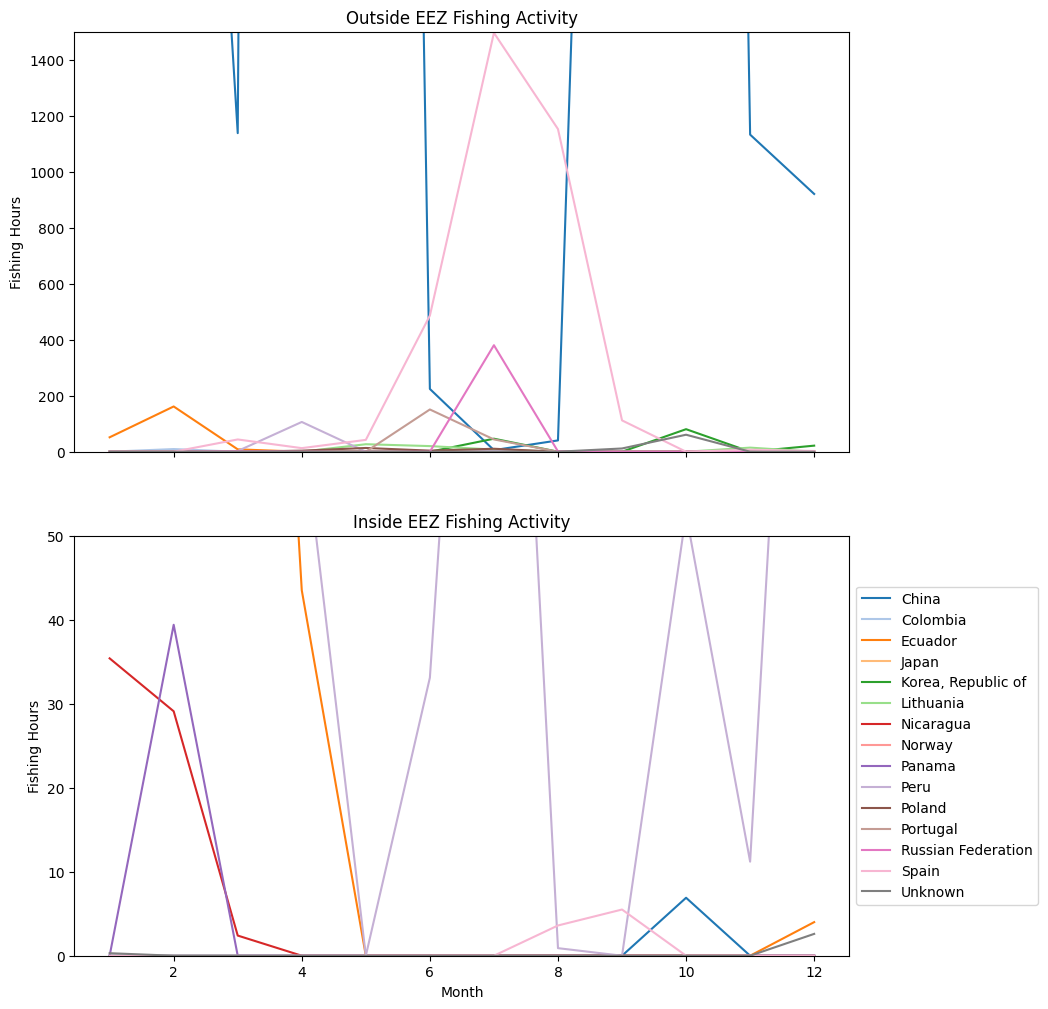

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

x = months

# OUTSIDE EEZ
for country in all_countries:
    ax1.plot(x, data_f[country], label=country, color=color_map[country])

ax1.set_title("Outside EEZ Fishing Activity")
ax1.set_ylabel("Fishing Hours")
ax1.set_ylim(0, 1500)

# INSIDE EEZ
for country in all_countries:
    ax2.plot(x, data_t[country], label=country, color=color_map[country])

ax2.set_title("Inside EEZ Fishing Activity")
ax2.set_xlabel("Month")
ax2.set_ylabel("Fishing Hours")
ax2.set_ylim(0, 50)

ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()

## HEATMAP

In order to visualize the yearly fishing data geo-spatially, we make a heatmap from our aggregated annual data set.

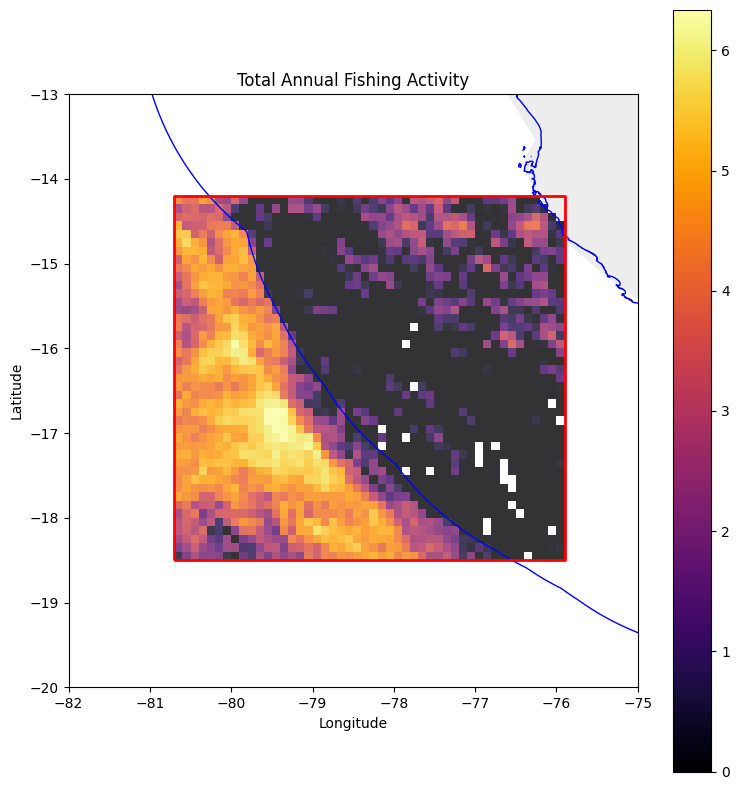

In [10]:
from shapely.geometry import box
from matplotlib.colors import LogNorm

df = pd.read_csv(BASE_DIR / "data/processed_validated/peru_region_2024_full_validated.csv")


# group fishing activity per grid cell
agg = (
    df.groupby(["cell_ll_lat", "cell_ll_lon"], as_index=False)
      .agg({"fishing_hours": "sum"})
)


# convert to geodataframe
cell_size = 0.1  # degrees

agg["geometry"] = agg.apply(
    lambda row: box(
        row["cell_ll_lon"],
        row["cell_ll_lat"],
        row["cell_ll_lon"] + cell_size,
        row["cell_ll_lat"] + cell_size
    ),
    axis=1
)

heatmap_gdf = gpd.GeoDataFrame(agg, geometry="geometry", crs="EPSG:4326")

# log transform
heatmap_gdf["log_fishing"] = np.log1p(heatmap_gdf["fishing_hours"])

study_gdf = gpd.GeoDataFrame(
    geometry=[box(-80.7, -18.5, -75.9, -14.2)],
    crs="EPSG:4326"
)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")


def plot_map(ax, xlim, ylim, title):
    # base layers
    world.plot(ax=ax, color="lightgrey", alpha=0.4)
    eez.boundary.plot(ax=ax, color="blue", linewidth=1)
    study_gdf.boundary.plot(ax=ax, color="red", linewidth=2)

    # heatmap layer
    heatmap_gdf.plot(
        ax=ax,
        column="log_fishing", 
        cmap="inferno",
        legend=True,
        alpha=0.8
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig, ax = plt.subplots(figsize=(8, 8))

plot_map(
    ax,
    (-82, -75),
    (-20, -13),
    "Total Annual Fishing Activity"
)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/maps/yearly_heatmap.png")
plt.show()